# Global Air Pollution Analysis using Logistic Regression

## Objective

The objective of this project is to analyse a global air pollution dataset, preprocess the data, visualize important patterns, prepare the dataset for machine learning, and build a Logistic Regression model to classify the Air Quality Index (AQI) category.

The project includes data exploration, handling missing values, encoding categorical features, feature scaling, model training, prediction, evaluation, and interpretation of results.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("global air pollution dataset.csv")

df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


# Dataset Overview

This dataset contains air pollution measurements collected from different cities and countries around the world.

It includes Air Quality Index (AQI) values along with pollutant concentrations such as Carbon Monoxide (CO), Ozone (O₃), Nitrogen Dioxide (NO₂), and PM2.5.

The dataset is suitable for classification because it contains the **AQI Category**, which represents different levels of air quality.

In [6]:
print("Dataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

Dataset Shape
(23463, 12)

Column Names
Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 

# Dataset Understanding

### General Observations

- The dataset contains air quality information collected from different countries and cities.
- It includes both numerical and categorical features.
- The numerical columns represent AQI values of different pollutants.
- The categorical columns represent countries, cities and AQI categories.
- Some missing values may be present and should be handled before training the model.

# Handling Missing Values

The dataset contains only two columns with missing values.

- **Country** has 427 missing values.
- **City** has 1 missing value.

Since both are categorical columns, the missing values are replaced using the **mode (most frequently occurring value)**.

This approach preserves the dataset size and avoids unnecessary data loss.

In [7]:
# Fill missing values using mode

df["Country"] = df["Country"].fillna(df["Country"].mode()[0])
df["City"] = df["City"].fillna(df["City"].mode()[0])

print("Missing Values After Cleaning")
print(df.isnull().sum())

Missing Values After Cleaning
Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
dtype: int64


# Generalization and Relationship Between Features

### Overall Observations

- AQI Value determines the overall air quality category.
- Higher PM2.5 AQI values generally indicate poorer air quality.
- Increased CO AQI values contribute to higher pollution levels.
- Higher Ozone AQI values can negatively affect air quality.
- NO₂ AQI values also influence the overall AQI category.
- Countries and cities experience different pollution levels due to geographical and environmental factors.
- Pollutant AQI values together determine the final AQI Category.

# Feature Engineering

No additional feature engineering was required because the dataset already contains meaningful pollutant measurements and AQI indicators suitable for classification.

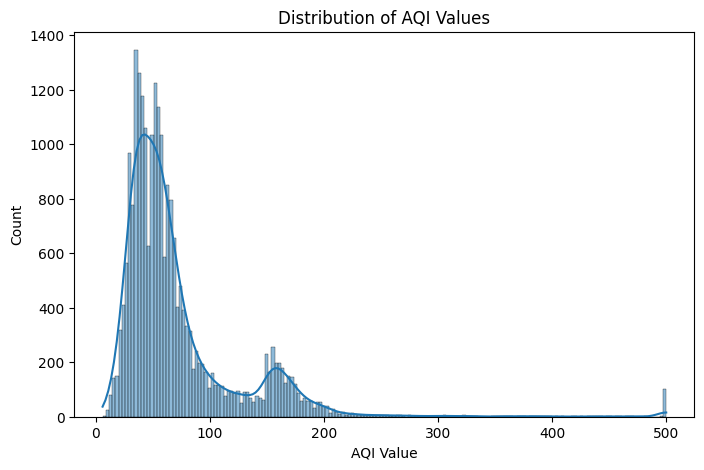

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["AQI Value"], kde=True)

plt.title("Distribution of AQI Values")

plt.show()

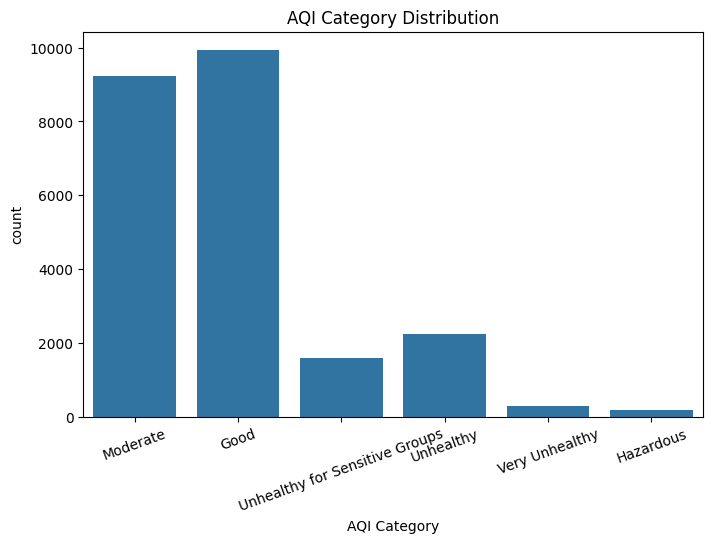

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(x="AQI Category", data=df)

plt.xticks(rotation=20)

plt.title("AQI Category Distribution")

plt.show()

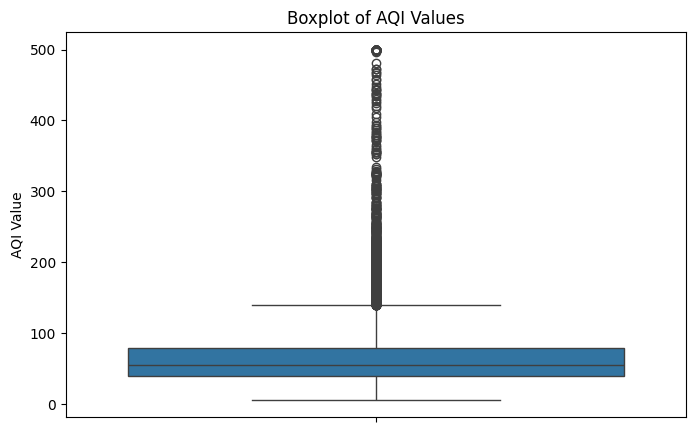

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["AQI Value"])

plt.title("Boxplot of AQI Values")

plt.show()

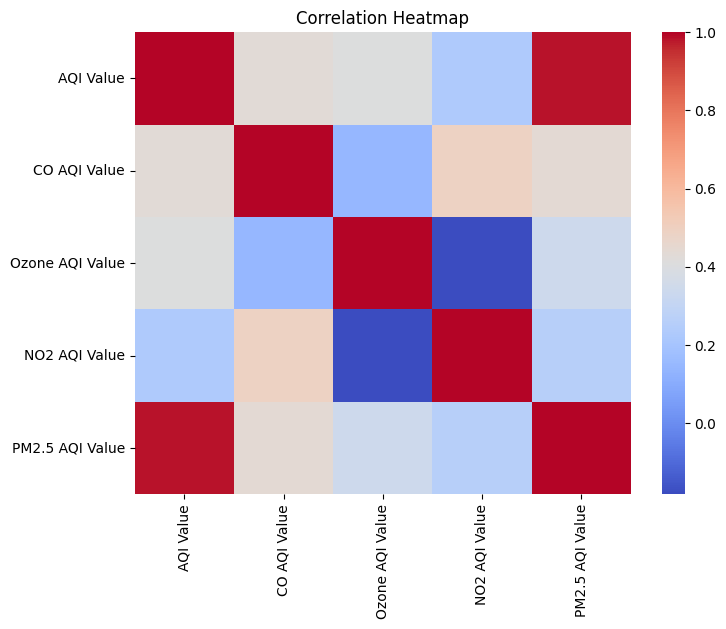

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Visualization Insights

- The histogram shows the distribution of AQI values.
- The count plot displays the number of records in each AQI category.
- The box plot helps identify outliers in AQI values.
- The heatmap illustrates the correlation between numerical pollutant measurements.

# Encoding Categorical Data

Machine learning algorithms cannot process text values directly.

Therefore, categorical columns are converted into numerical values using **LabelEncoder**. This transformation allows the Logistic Regression model to use these features for classification.

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Country   City  AQI Value  AQI Category  CO AQI Value  CO AQI Category  \
0      130  16525         51             2             1                0   
1       22  16546         41             0             1                0   
2       75  16582         66             2             1                0   
3      123  16618         34             0             1                0   
4       54  16699         22             0             0                0   

   Ozone AQI Value  Ozone AQI Category  NO2 AQI Value  NO2 AQI Category  \
0               36                   0              0                 0   
1                5                   0              1                 0   
2               39                   0              2                 0   
3               34                   0              0                 0   
4               22                   0              0                 0   

   PM2.5 AQI Value  PM2.5 AQI Category  
0               51                   2  
1   

# Feature Scaling

Feature scaling is applied using **StandardScaler** to bring all numerical features to a similar scale.

Scaling improves the performance and stability of many machine learning algorithms, including Logistic Regression.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop("AQI Category", axis=1)
y = df["AQI Category"]

X = scaler.fit_transform(X)

# Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used to train the model.
- 20% of the data is used to evaluate the model on unseen data.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (18770, 11)
Testing Shape: (4693, 11)


# Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for classification problems.

In this project, it is used to classify the **AQI Category** based on different air pollution measurements.

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Model Prediction

After training the Logistic Regression model, predictions are generated using the testing dataset.

These predicted values are compared with the actual AQI categories to evaluate the model's performance.

In [16]:
y_pred = model.predict(X_test)

print("Predicted AQI Categories:")
print(y_pred[:10])

Predicted AQI Categories:
[2 0 0 2 0 2 0 0 2 5]


# Model Evaluation

The Logistic Regression model is evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report

These metrics help determine how well the model classifies air quality categories.

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9970168335819305


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2014    0    0    0    0    0]
 [   0   38    0    0    0    4]
 [   0    0 1837    0    0    0]
 [   0    0    0  416    3    0]
 [   0    0    1    6  314    0]
 [   0    0    0    0    0   60]]


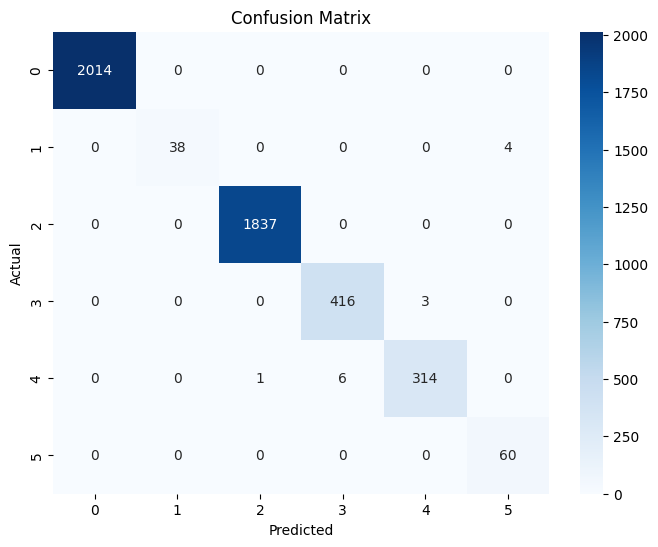

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2014
           1       1.00      0.90      0.95        42
           2       1.00      1.00      1.00      1837
           3       0.99      0.99      0.99       419
           4       0.99      0.98      0.98       321
           5       0.94      1.00      0.97        60

    accuracy                           1.00      4693
   macro avg       0.99      0.98      0.98      4693
weighted avg       1.00      1.00      1.00      4693



In [21]:
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.9970168335819305
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2014
           1       1.00      0.90      0.95        42
           2       1.00      1.00      1.00      1837
           3       0.99      0.99      0.99       419
           4       0.99      0.98      0.98       321
           5       0.94      1.00      0.97        60

    accuracy                           1.00      4693
   macro avg       0.99      0.98      0.98      4693
weighted avg       1.00      1.00      1.00      4693



# Final Insights

## Model Summary

- The dataset was successfully analysed and preprocessed.
- Missing values in the **Country** and **City** columns were handled using the mode.
- Categorical columns were converted into numerical format using **LabelEncoder**.
- Numerical features were standardized using **StandardScaler**.
- The dataset was divided into training and testing sets using an 80:20 ratio.
- A Logistic Regression model was trained to classify AQI categories based on air pollution measurements.

## Model Performance

- The model achieved an **Accuracy of 99.70%**, indicating excellent classification performance.
- The Classification Report shows very high Precision, Recall, and F1-score for almost all AQI categories.
- The weighted average Precision, Recall, and F1-score are approximately **1.00**, demonstrating that the model performs consistently across the dataset.
- Only a few samples from smaller classes were misclassified, while the majority were classified correctly.

## Conclusion

The Logistic Regression model performed exceptionally well in classifying AQI categories. The high accuracy and strong evaluation metrics indicate that the selected pollution-related features are highly effective for predicting air quality categories. The model can be considered reliable for this classification task.